# 01 - Exploratory Data Analysis

**Criteo Uplift v2.1: who should a budget-constrained campaign contact?**

A campaign can reach 5% of eligible users. The incumbent ranks users by how
likely they are to respond. This notebook explores whether that is the right
question, and establishes what the data can and cannot support.

What this notebook covers:

1. Load the data and check its integrity
2. Target variables: visit and conversion
3. Verify the randomization the whole project rests on
4. Feature distributions
5. Why response probability is not the campaign's objective
6. A column that must be excluded, and the evidence for excluding it
7. Duplicate rows, and why they change how samples are drawn

Every analysis here runs on a development sample. The confirmatory sample is
opened once, at the end of the project, and never during exploration.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.criteo import CRITEO_FEATURE_COLUMNS, load_criteo

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 9,
    }
)

TEAL, GREY, CORAL = "#0E6E64", "#8A8A80", "#C1553B"
print(f"Project root: {ROOT}")

Project root: D:\code\Vinsmart Future


## 1. Load the data

The source file is 13,979,592 rows and does not fit comfortably in memory, so
the project draws reproducible samples from it. This notebook uses the
development sample of 500,000 rows.

In [2]:
SAMPLE = ROOT / "data" / "processed" / "criteo_sample_500k.parquet"
dataset = load_criteo(SAMPLE, outcome="visit")
frame = dataset.raw

print(f"Rows:     {len(frame):,}")
print(f"Columns:  {frame.shape[1]}")
print(f"Memory:   {frame.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")
frame.head()

Rows:     500,000
Columns:  17
Memory:   64.8 MB


,row_id,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,1446581,25.832713,10.059654,8.714944,4.679882,11.029584,4.115453,-1.288207,4.833815,3.852313,13.190056,6.414643,-0.168679,1,0,0,0
1,866989,15.624249,10.059654,8.628178,3.907662,10.280525,4.115453,-12.781218,4.833815,3.835145,23.570168,5.300375,-0.168679,1,0,0,0
2,10723676,12.616365,10.059654,8.704927,4.679882,10.280525,4.115453,0.294443,4.833815,3.847294,13.190056,5.300375,-0.168679,1,0,0,0
3,7407883,17.200682,10.059654,8.291456,-0.205137,11.029584,4.115453,-10.764422,4.833815,3.758720,46.047869,5.821674,-0.267350,1,0,0,0
4,8940674,25.475107,10.059654,8.214383,4.679882,10.280525,4.115453,-3.993764,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0


### Schema and integrity

Before any analysis, three questions: what type is each column, are there
missing values, and are the flags actually binary.

In [3]:
integrity = pd.DataFrame(
    {
        "dtype": frame.dtypes.astype(str),
        "missing": frame.isna().sum(),
        "n_unique": frame.nunique(),
        "min": frame.min(numeric_only=True),
        "max": frame.max(numeric_only=True),
    }
)
integrity

,dtype,missing,n_unique,min,max
row_id,int64,0,500000,1.000000,1.397959e+07
f0,float64,0,328836,12.616365,2.674525e+01
f1,float64,0,23,10.059654,1.419961e+01
f2,float64,0,221388,8.214383,9.051961e+00
f3,float64,0,342,-7.700578,4.679882e+00
f4,float64,0,105,10.280525,1.966795e+01
f5,float64,0,52,-6.601022,4.115453e+00
f6,float64,0,902,-30.159875,2.944427e-01
f7,float64,0,26526,4.833815,1.199840e+01
f8,float64,0,1711,3.651810,3.971858e+00


In [4]:
binary_columns = ["treatment", "visit", "conversion", "exposure"]
for column in binary_columns:
    values = set(frame[column].unique())
    status = "binary" if values <= {0, 1} else f"NOT binary: {sorted(values)}"
    print(f"{column:12s} {status}")

print(f"\nTotal missing values in the frame: {frame.isna().sum().sum()}")

treatment    binary
visit        binary
conversion   binary
exposure     binary

Total missing values in the frame: 0


No missing values, and every flag is a clean 0/1. The 12 features `f0` to
`f11` are anonymised floats, so no domain interpretation is available and
none is assumed.

## 2. Target variables

Two outcomes are available. `visit` means the user reached the site,
`conversion` means they completed a purchase. They differ by a factor of
roughly 16 in base rate, which turns out to matter a great deal for how much
an experiment can resolve.

In [5]:
targets = pd.DataFrame(
    {
        "positives": [frame["visit"].sum(), frame["conversion"].sum()],
        "rate_pct": [
            100 * frame["visit"].mean(),
            100 * frame["conversion"].mean(),
        ],
    },
    index=["visit", "conversion"],
)
targets["one_in"] = (100 / targets["rate_pct"]).round(0)
targets

,positives,rate_pct,one_in
visit,23797,4.7594,21.0
conversion,1473,0.2946,339.0


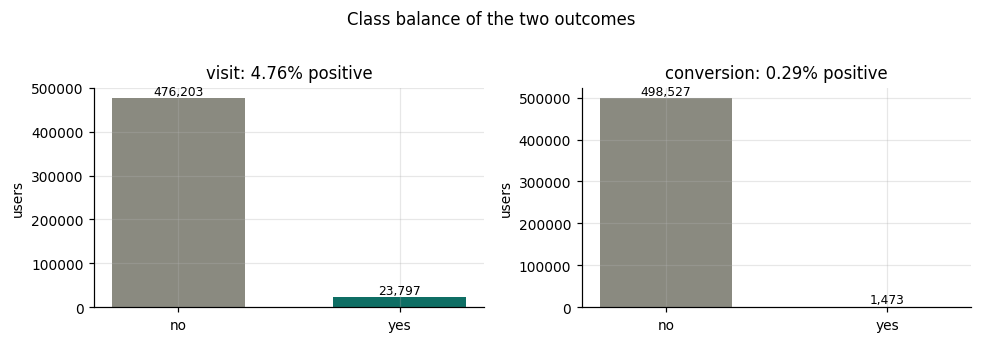

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, name in zip(axes, ["visit", "conversion"], strict=True):
    counts = frame[name].value_counts().sort_index()
    ax.bar(["no", "yes"], counts.to_numpy(), color=[GREY, TEAL], width=0.6)
    rate = 100 * frame[name].mean()
    ax.set_title(f"{name}: {rate:.2f}% positive")
    ax.set_ylabel("users")
    for i, value in enumerate(counts.to_numpy()):
        ax.text(i, value, f"{value:,}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Class balance of the two outcomes", y=1.02)
fig.tight_layout()
plt.show()

Conversion is a rare event at 0.29%. Any method applied to it has to survive
that rarity, which is why the project sweeps negative undersampling for the
conversion arm and not for visit.

## 3. The randomization check

This is the single most important cell in the notebook. Every causal claim
the project makes depends on treatment being randomly assigned. If it is not,
then no amount of modelling recovers a causal effect.

Two things to verify: the assignment ratio, and whether the two arms look
alike on features measured before assignment.

In [7]:
assignment = frame["treatment"].value_counts().sort_index()
propensity = frame["treatment"].mean()
print(f"Control (T=0): {assignment[0]:,}  ({100 * (1 - propensity):.2f}%)")
print(f"Treated (T=1): {assignment[1]:,}  ({100 * propensity:.2f}%)")
print(f"\nPropensity e = {propensity:.6f}")
print(
    "\nThe design is deliberately unbalanced at roughly 85/15. Several uplift\n"
    "estimators assume a balanced design and need reweighting because of this."
)

Control (T=0): 74,948  (14.99%)
Treated (T=1): 425,052  (85.01%)

Propensity e = 0.850104

The design is deliberately unbalanced at roughly 85/15. Several uplift
estimators assume a balanced design and need reweighting because of this.


### Covariate balance

In a randomized trial the two arms should be statistically indistinguishable
on every pre-treatment covariate. The standardised mean difference measures
this on a scale that does not depend on the unit of the feature. A common
rule of thumb treats anything above 0.1 as a meaningful imbalance.

In [8]:
treated = frame.loc[frame["treatment"] == 1, CRITEO_FEATURE_COLUMNS]
control = frame.loc[frame["treatment"] == 0, CRITEO_FEATURE_COLUMNS]

pooled_sd = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2.0)
balance = pd.DataFrame(
    {
        "mean_treated": treated.mean(),
        "mean_control": control.mean(),
        "std_mean_diff": (treated.mean() - control.mean()) / pooled_sd,
    }
)
balance["abs_smd"] = balance["std_mean_diff"].abs()
balance.sort_values("abs_smd", ascending=False)

,mean_treated,mean_control,std_mean_diff,abs_smd
f3,4.168902,4.227924,-0.045101,0.045101
f6,-4.181820,-4.019877,-0.035678,0.035678
f5,4.025871,4.038260,-0.029448,0.029448
f1,10.070654,10.067843,0.027983,0.027983
f7,5.106949,5.081037,0.021753,0.021753
f8,3.933381,3.934594,-0.021576,0.021576
f9,16.047643,15.900576,0.021157,0.021157
f0,19.609352,19.644440,-0.006521,0.006521
f10,5.333283,5.332756,0.003146,0.003146
f11,-0.171024,-0.170973,-0.002191,0.002191


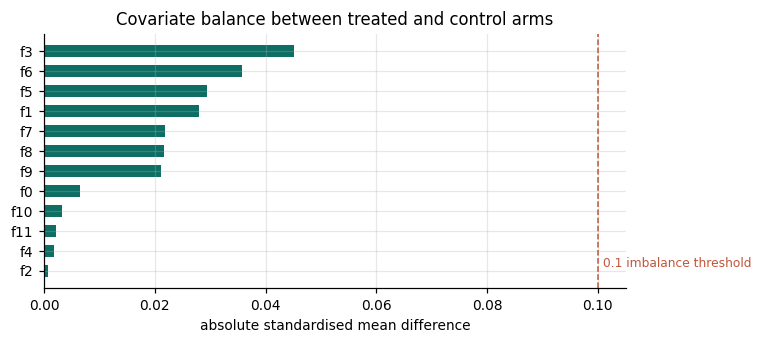

Largest absolute SMD: 0.0451


In [9]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ordered = balance.sort_values("abs_smd")
ax.barh(ordered.index, ordered["abs_smd"], color=TEAL, height=0.6)
ax.axvline(0.1, color=CORAL, linestyle="--", linewidth=1)
ax.text(0.101, 0.2, "0.1 imbalance threshold", color=CORAL, fontsize=8)
ax.set_xlabel("absolute standardised mean difference")
ax.set_title("Covariate balance between treated and control arms")
fig.tight_layout()
plt.show()

print(f"Largest absolute SMD: {balance['abs_smd'].max():.4f}")

Every feature sits far below the threshold. The randomization holds, which
means the propensity is *known* rather than estimated. That is a stronger
position than most observational work and it is what makes the doubly robust
estimator used later unbiased by construction.

## 4. Feature distributions

The features are anonymised, so the useful question is not what they mean but
whether any of them is degenerate, constant, or so skewed that a tree model
would struggle.

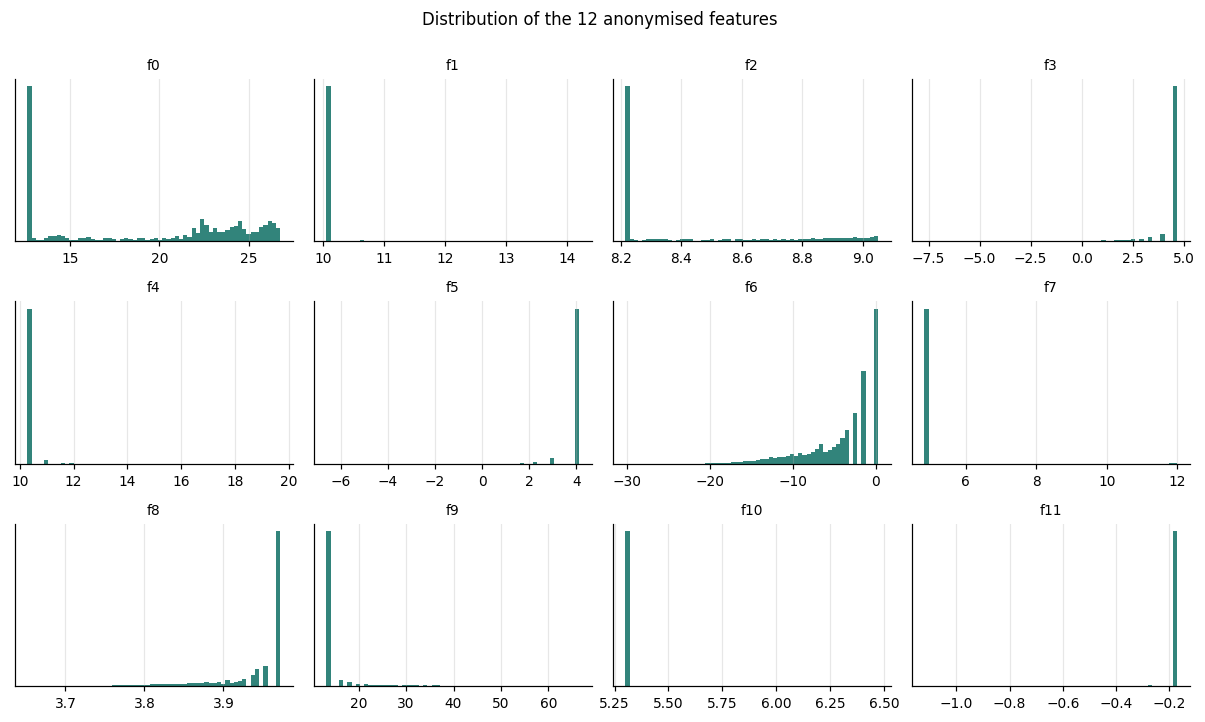

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(11, 6.5))
for ax, column in zip(axes.ravel(), CRITEO_FEATURE_COLUMNS, strict=True):
    ax.hist(frame[column], bins=60, color=TEAL, alpha=0.85)
    ax.set_title(column, fontsize=9)
    ax.set_yticks([])
fig.suptitle("Distribution of the 12 anonymised features", y=1.0)
fig.tight_layout()
plt.show()

In [11]:
summary = frame[CRITEO_FEATURE_COLUMNS].describe().T
summary["skew"] = frame[CRITEO_FEATURE_COLUMNS].skew()
summary["n_unique"] = frame[CRITEO_FEATURE_COLUMNS].nunique()
summary[["mean", "std", "min", "max", "skew", "n_unique"]]

,mean,std,min,max,skew,n_unique
f0,19.614612,5.377441,12.616365,26.745245,-0.244288,328836
f1,10.070233,0.106560,10.059654,14.199609,13.647931,23
f2,8.446804,0.299612,8.214383,9.051961,0.805291,221388
f3,4.177749,1.341767,-7.700578,4.679882,-3.189860,342
f4,10.339283,0.347149,10.280525,19.667949,8.922231,105
f5,4.027728,0.434129,-6.601022,4.115453,-7.049719,52
f6,-4.157545,4.582983,-30.159875,0.294443,-1.134135,902
f7,5.103065,1.207722,4.833815,11.998397,4.512468,26526
f8,3.933563,0.056678,3.651810,3.971858,-1.604043,1711
f9,16.025598,7.026291,13.190056,66.496494,2.827961,747


Several features are heavily concentrated on a few values, and `f8` in
particular is close to constant. Nothing here is dropped: the models are
gradient-boosted trees, which handle low-cardinality and skewed inputs
without transformation, and dropping a feature is a decision that would
itself need justifying.

## 5. Why response probability is not the objective

The incumbent ranks by `P(Y = 1 | X, T = 1)`, the probability that a user
responds given they were contacted. The problem with that is visible in a
single comparison.

In [12]:
rate_treated = frame.loc[frame["treatment"] == 1, "visit"].mean()
rate_control = frame.loc[frame["treatment"] == 0, "visit"].mean()
lift = rate_treated - rate_control

comparison = pd.DataFrame(
    {
        "visit_rate_pct": [100 * rate_control, 100 * rate_treated],
        "users": [(frame["treatment"] == 0).sum(), (frame["treatment"] == 1).sum()],
    },
    index=["not contacted", "contacted"],
)
print(comparison)
print(f"\nDifference (average treatment effect): {100 * lift:+.4f} pp")
print(f"Share of contacted visitors that the campaign caused: {lift / rate_treated:.1%}")

               visit_rate_pct   users
not contacted        3.942734   74948
contacted            4.903400  425052

Difference (average treatment effect): +0.9607 pp
Share of contacted visitors that the campaign caused: 19.6%


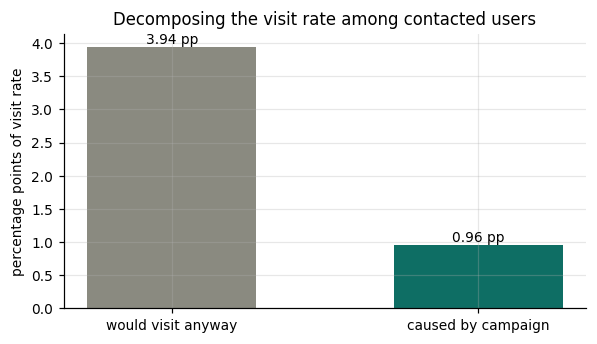

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(
    ["would visit anyway", "caused by campaign"],
    [100 * rate_control, 100 * lift],
    color=[GREY, TEAL],
    width=0.55,
)
ax.set_ylabel("percentage points of visit rate")
ax.set_title("Decomposing the visit rate among contacted users")
ax.text(0, 100 * rate_control, f"{100 * rate_control:.2f} pp", ha="center", va="bottom")
ax.text(1, 100 * lift, f"{100 * lift:.2f} pp", ha="center", va="bottom")
fig.tight_layout()
plt.show()

Of the users who visit after being contacted, roughly three quarters would
have visited regardless. A response model learns to find that larger group,
because that is what it was trained to predict. The campaign wants the other
group.

The quantity it actually wants is

$$\text{uplift}(X) = P(Y = 1 \mid X, T = 1) - P(Y = 1 \mid X, T = 0)$$

which is never observed for anybody: each user appears in one arm only. There
is no label to train on and none to validate against. That single fact drives
the entire evaluation design in notebooks 02 and 03.

## 6. A column that has to be excluded

The dataset carries an `exposure` flag recording whether the ad actually
rendered. It looks like a strong predictor. It is decided *after* assignment,
which makes it dangerous.

In [14]:
groups = pd.DataFrame(
    [
        {
            "group": "not assigned",
            "users": int((frame["treatment"] == 0).sum()),
            "visit_pct": 100 * frame.loc[frame["treatment"] == 0, "visit"].mean(),
        },
        {
            "group": "assigned, ad never rendered",
            "users": int(((frame["treatment"] == 1) & (frame["exposure"] == 0)).sum()),
            "visit_pct": 100
            * frame.loc[
                (frame["treatment"] == 1) & (frame["exposure"] == 0), "visit"
            ].mean(),
        },
        {
            "group": "assigned, ad rendered",
            "users": int(((frame["treatment"] == 1) & (frame["exposure"] == 1)).sum()),
            "visit_pct": 100
            * frame.loc[
                (frame["treatment"] == 1) & (frame["exposure"] == 1), "visit"
            ].mean(),
        },
    ]
)
groups

,group,users,visit_pct
0,not assigned,74948,3.942734
1,"assigned, ad never rendered",409728,3.517211
2,"assigned, ad rendered",15324,41.966849


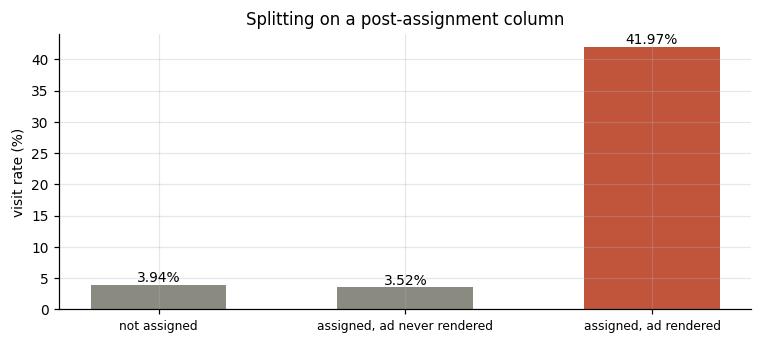

Apparent effect of a rendered ad: +38.02 pp


In [15]:
fig, ax = plt.subplots(figsize=(7, 3.2))
colors = [GREY, GREY, CORAL]
ax.bar(groups["group"], groups["visit_pct"], color=colors, width=0.55)
for i, value in enumerate(groups["visit_pct"]):
    ax.text(i, value, f"{value:.2f}%", ha="center", va="bottom")
ax.set_ylabel("visit rate (%)")
ax.set_title("Splitting on a post-assignment column")
ax.tick_params(axis="x", labelsize=8)
fig.tight_layout()
plt.show()

naive_gap = groups.loc[2, "visit_pct"] - groups.loc[0, "visit_pct"]
print(f"Apparent effect of a rendered ad: {naive_gap:+.2f} pp")

### The evidence that this is not an effect

Compare the first two rows. Users who were assigned but never saw the ad
visit *less often* than users never assigned at all. Sending an ad cannot
make somebody less likely to act, so that ordering is not causal. It shows
the split has selected on the outcome.

The mechanism is simple: an ad renders only while the user is already
browsing, so `exposure = 1` marks people who were already on their way to the
site. Conditioning on it is collider bias.

In [16]:
unexposed_rate = groups.loc[1, "visit_pct"]
control_rate = groups.loc[0, "visit_pct"]
print(f"assigned, ad never rendered : {unexposed_rate:.3f}%")
print(f"not assigned                : {control_rate:.3f}%")
print(f"difference                  : {unexposed_rate - control_rate:+.3f} pp")
print(
    "\nA negative number here is impossible under an intact randomization,\n"
    "so the grouping variable, not the campaign, is producing it."
)

exposure_rate = frame.loc[frame["treatment"] == 1, "exposure"].mean()
print(f"\nShare of assigned users whose ad rendered: {100 * exposure_rate:.4f}%")

assigned, ad never rendered : 3.517%
not assigned                : 3.943%
difference                  : -0.426 pp

A negative number here is impossible under an intact randomization,
so the grouping variable, not the campaign, is producing it.

Share of assigned users whose ad rendered: 3.6052%


`exposure` is therefore dropped from every feature set. The question it
raises is still answerable, but with an instrumental-variable estimator
rather than a subgroup comparison, and that is done in notebook 03.

## 7. Duplicate rows change how samples must be drawn

The project needs several disjoint samples: one to develop on, one to select
the model on, one to report the final number on. The obvious way to keep them
disjoint is to exclude rows by value. Measuring the duplicates first shows why
that would be a mistake.

In [17]:
import duckdb

INDEXED = ROOT / "data" / "processed" / "criteo_indexed.parquet"
# Two rows are duplicates when every recorded value agrees. row_id is excluded
# because it is the identifier, not a value: that is exactly the distinction
# this section is about.
value_columns = ", ".join(
    [*CRITEO_FEATURE_COLUMNS, "treatment", "conversion", "visit", "exposure"]
)
connection = duckdb.connect()
connection.execute("SET enable_progress_bar = false")
duplicate_stats = connection.sql(
    f"""
    WITH tagged AS (
        SELECT
            treatment,
            visit,
            count(*) OVER (PARTITION BY {value_columns}) AS copies
        FROM read_parquet('{INDEXED.as_posix()}')
    )
    SELECT
        CASE WHEN copies > 1 THEN 'values duplicated elsewhere' ELSE 'values unique' END
            AS group_name,
        count(*) AS rows,
        100 * avg(treatment) AS treated_pct,
        100 * (
            avg(CASE WHEN treatment = 1 THEN visit END)
            - avg(CASE WHEN treatment = 0 THEN visit END)
        ) AS visit_effect_pp
    FROM tagged
    GROUP BY 1
    ORDER BY rows
    """
).df()
connection.close()
duplicate_stats

,group_name,rows,treated_pct,visit_effect_pp
0,values duplicated elsewhere,2221150,95.712987,0.001976
1,values unique,11758442,82.976350,1.909818


In [18]:
duplicated = duplicate_stats.set_index("group_name").loc["values duplicated elsewhere"]
unique = duplicate_stats.set_index("group_name").loc["values unique"]
print(f"Duplicated rows : {int(duplicated['rows']):>11,}  "
      f"treated {duplicated['treated_pct']:.2f}%  "
      f"effect {duplicated['visit_effect_pp']:+.4f} pp")
print(f"Unique rows     : {int(unique['rows']):>11,}  "
      f"treated {unique['treated_pct']:.2f}%  "
      f"effect {unique['visit_effect_pp']:+.4f} pp")
print(
    f"\nThe duplicated group carries "
    f"{unique['visit_effect_pp'] / duplicated['visit_effect_pp']:.0f}x less effect "
    "per row than the unique group."
)

Duplicated rows :   2,221,150  treated 95.71%  effect +0.0020 pp
Unique rows     :  11,758,442  treated 82.98%  effect +1.9098 pp

The duplicated group carries 967x less effect per row than the unique group.


The duplicated rows are close to inert: overwhelmingly treated, and carrying
almost no treatment effect. Excluding by value would drop *every* copy the
moment one is drawn, so each successive sample would shed more of this inert
group and its measured treatment effect would drift upward relative to the
population.

The project therefore excludes by `row_id`, the row's position in the source
file, which removes exactly the rows already spent and nothing else. What
looked like the conservative choice was the biased one.

## Summary

| Finding | Consequence for the rest of the project |
|---|---|
| No missing values, clean binary flags | No imputation step is needed |
| Assignment is randomized, largest SMD well under 0.1 | Propensity is known, not estimated |
| Design is 85/15, not balanced | Estimators assuming balance need reweighting |
| Roughly three quarters of contacted visitors would visit anyway | Response ranking is not the campaign objective |
| Uplift is never observed per user | Evaluation cannot use accuracy or AUC |
| `exposure` is post-assignment and selects on the outcome | Dropped from features, handled separately by an IV estimator |
| Duplicate rows are inert and numerous | Samples are made disjoint by row identity, not by value |
| Conversion base rate is 0.29% | The rare-outcome arm needs its own treatment |

Notebook 02 builds the candidate models and the selection protocol.